In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [162]:
data = pd.read_csv("../data/Telco-Customer-Churn.csv")
data.shape
print(f"We have a dataset with {data.shape[0]} rows and {data.shape[1]} columns")
data.head(10)

We have a dataset with 7043 rows and 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [163]:
data_dictionary = {
    "customerID": "This column contains the unique identifier assigned to each individual customer.",
    "gender": "This column indicates the biological gender of the customer.",
    "SeniorCitizen": "This column specifies whether the customer is classified as a senior citizen (0 for No, 1 for Yes).",
    "Partner": "This column indicates whether the customer has a partner or is married.",
    "Dependents": "This column indicates whether the customer has dependents living with them.",
    "tenure": "This column represents the total number of months the customer has stayed with the company.",
    "PhoneService": "This column indicates whether the customer subscribes to a home phone service.",
    "MultipleLines": "This column indicates whether the customer has multiple telephone lines activated.",
    "InternetService": "This column specifies the type of internet service provider technology the customer uses.",
    "OnlineSecurity": "This column indicates whether the customer has subscribed to an additional online security add-on.",
    "OnlineBackup": "This column indicates whether the customer has subscribed to an online data backup service.",
    "DeviceProtection": "This column indicates whether the customer has device protection insurance for their equipment.",
    "TechSupport": "This column indicates whether the customer has subscribed to an extra technical support plan.",
    "StreamingTV": "This column indicates whether the customer uses their internet service to stream television programs.",
    "StreamingMovies": "This column indicates whether the customer uses their internet service to stream movies.",
    "Contract": "This column describes the duration of the customer's current contract.",
    "PaperlessBilling": "This column indicates whether the customer has chosen to receive paperless billing statements.",
    "PaymentMethod": "This column specifies the payment method used by the customer.",
    "MonthlyCharges": "This column represents the amount charged to the customer on a monthly basis.",
    "TotalCharges": "This column represents the total cumulative amount charged to the customer over their entire tenure.",
    "Churn": "This column indicates whether the customer churned by canceling their service during the evaluated period."
}

In [164]:
 for key, val in data_dictionary.items():
     print("__"* 50)
     print(f"{key}  {val} \n \n")

____________________________________________________________________________________________________
customerID  This column contains the unique identifier assigned to each individual customer. 
 

____________________________________________________________________________________________________
gender  This column indicates the biological gender of the customer. 
 

____________________________________________________________________________________________________
SeniorCitizen  This column specifies whether the customer is classified as a senior citizen (0 for No, 1 for Yes). 
 

____________________________________________________________________________________________________
Partner  This column indicates whether the customer has a partner or is married. 
 

____________________________________________________________________________________________________
Dependents  This column indicates whether the customer has dependents living with them. 
 

_____________________________

In [165]:
data.info()
print('##' * 40)
print('##' * 40)
print(f'\n  Categorical columns:\n{data.select_dtypes(include="object").columns.to_list()}\n')
print('##' * 40)
print(f'  Numerical columns:\n{data.select_dtypes(include="number").columns.to_list()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Let's carefully note the `TotalCharges` feature, which contains numbers but is considered an object.
Why does this happen?
In this data, there are exactly 11 customers who have just subscribed to their service. Their subscription duration (`tenure`) is 0 months. Since they haven't received a cumulative bill yet, the `TotalCharges` field wasn't filled with a 0, but with a simple empty space (" ").

When Pandas imports the file, it scans the column. When it encounters these empty spaces, it cannot read them as numbers. As a safety measure, it decides that the entire column must be treated as text (`object`).
 


In [166]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')


In [167]:
print(f' Numerical columns:\n{data.select_dtypes(include="number").columns.to_list()}')

 Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## VALEURS MANQUANTES

In [168]:
missing = data.isnull().sum()
print(f"The number of missing values per feature is: \n {missing}")

The number of missing values per feature is: 
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


## VALEURS DUPLIQUEES

In [169]:
duplic = data.duplicated().sum()
print(f"The sum of duplicates in our dataset is: \n {duplic}")

The sum of duplicates in our dataset is: 
 0


## RESUME STATISTIQE DU DATASET

In [170]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [171]:
data.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


## UNIVARIATE ANALYSIS 

### Before continuing, we need to transform our target variable "Churn" to replace the text values with numbers 0 and 1 instead of Yes or No.

In [172]:
data["Churn"] = (data["Churn"] == "Yes").astype(int)

In [173]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Distribution of the target variable "Churn"

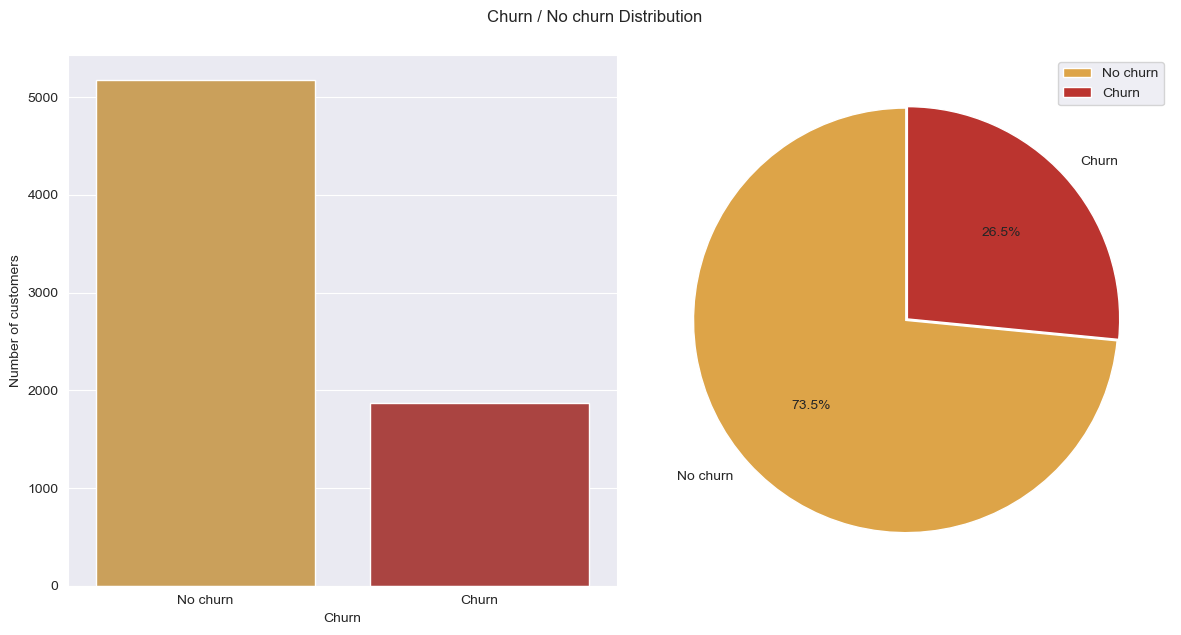

In [174]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Bar chart (Countplot)
sns.countplot(data=data, x="Churn", palette=["#DDA448", "#BB342F"], hue="Churn", legend=False, ax=ax[0])
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["No churn", "Churn"])
ax[0].set_ylabel("Number of customers")

# Pie chart - explicit grouping to match the 2 categories (0 and 1)
churn_counts = data["Churn"].value_counts().sort_index()
churn_counts.plot.pie(
    startangle=90, 
    labels=["No churn", "Churn"], 
    explode=(0, 0.01), 
    autopct='%1.1f%%', 
    colors=["#DDA448", "#BB342F"], 
    ax=ax[1]
)
ax[1].set_ylabel("") # Remove the y-label for better aesthetics
ax[1].legend()
fig.savefig("../data/target_distribution")

plt.tight_layout()
plt.suptitle("Churn / No churn Distribution", y=1.05)
plt.show()

## 📊 Interpretation: Target Variable Distribution (Churn)

* **Observation**: Out of 7,043 customers, 5,174 (73.5%) did not churn (**No churn**) while 1,869 (26.5%) churned (**Churn**). This shows a **moderate class imbalance** (ratio ~1:2.8).
* **Machine Learning implication**: This imbalance means accuracy alone is not a reliable metric (a model that always predicts "No churn" would already reach 73.5% accuracy). We should prioritize **F1-score**, **Recall** on the Churn class, and **AUC-ROC**, and consider `class_weight="balanced"` or resampling techniques (SMOTE) during modeling.

## CATEGORICAL FEATURES 

In [175]:
cat_feature = data.select_dtypes(include="object").columns.to_list()
cat_feature = cat_feature[1:]
cat_feature.append('SeniorCitizen')
cat_feature

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen']

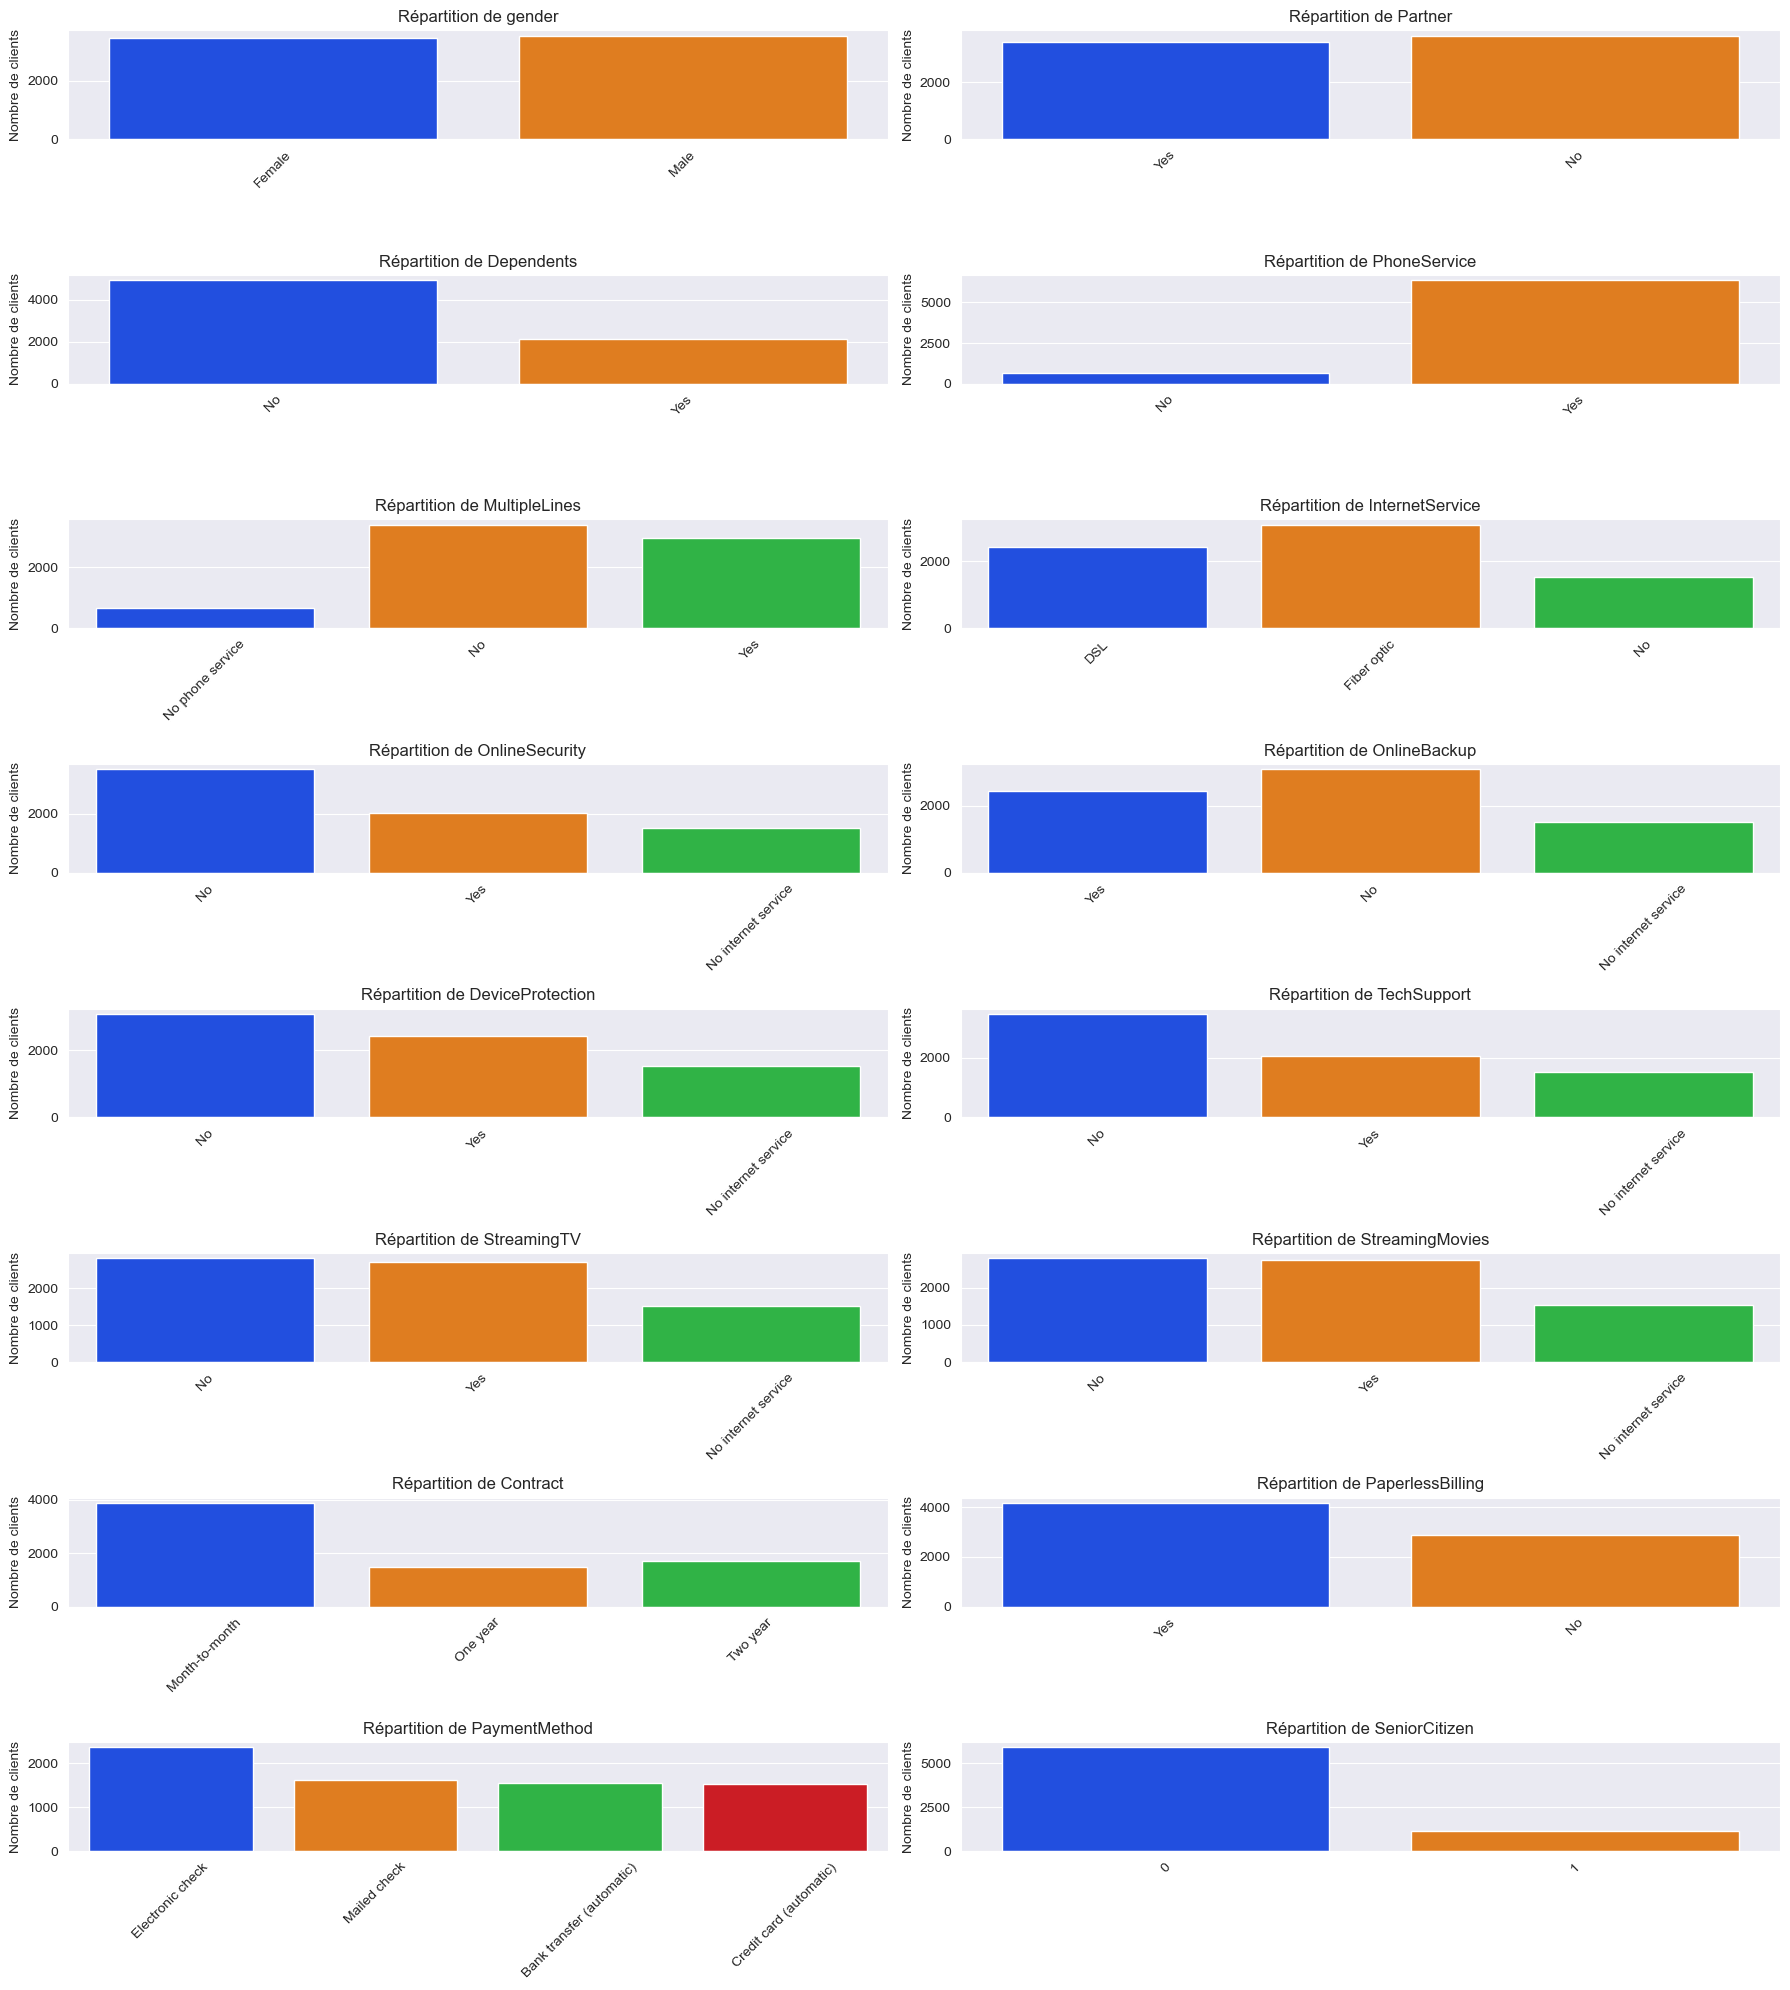

In [176]:
# 6 lignes et 3 colonnes pour accueillir tes 18 variables
fig, ax = plt.subplots(8, 2, figsize=(18, 20)) 
ax = ax.flatten()

for index, val in enumerate(cat_feature):
    sns.countplot(data=data, x=val, hue=val, palette="bright", ax=ax[index], legend=False)
    ax[index].set_title(f"Répartition de {val}")
    ax[index].set_ylabel("Nombre de clients") # Ajustement du texte
    ax[index].set_xlabel("") 
    ax[index].tick_params(axis='x', rotation=45) 
fig.savefig("../data/univariate_cat")
plt.tight_layout()
plt.show()

## 📊 Interpretation: Univariate Distribution of Categorical Variables

* **gender**: nearly perfectly balanced split between Female and Male (≈3,500 each) — not discriminative on its own for modeling purposes.

* **Partner**: slightly more customers without a partner (≈3,650) than with one (≈3,400) — a relatively close balance.

* **Dependents**: a strong majority of customers have no dependents (≈4,950) versus a minority with dependents (≈2,100) — an imbalanced variable.

* **PhoneService**: a very large majority of customers have phone service (≈6,350) versus a small minority who don't (≈680) — near-constant, so it carries little discriminative information on its own.

* **MultipleLines**: split across three categories — "No" (≈3,350), "Yes" (≈2,950), and "No phone service" (≈680, logically matching customers without PhoneService).

* **InternetService**: three well-represented categories — "Fiber optic" is the most common (≈3,100), followed by "DSL" (≈2,400) and "No" (≈1,500, customers without internet access).

* **OnlineSecurity / OnlineBackup / DeviceProtection / TechSupport**: a similar pattern across all four add-on services — "No" dominates by far (≈3,000–3,500), followed by "Yes" (≈2,000–2,400), and finally "No internet service" (≈1,500, consistent with the customers without internet identified above). This repeated pattern confirms that most customers with internet access do not subscribe to these additional services.

* **StreamingTV / StreamingMovies**: fairly balanced distribution between "No" and "Yes" (roughly 2,800 each), with the same "No internet service" share (≈1,500) seen in the previous variables.

* **Contract**: a very strong imbalance — "Month-to-month" dominates by far (≈3,900), well ahead of "Two year" (≈1,700) and "One year" (≈1,450). This distribution reflects the company's commercial structure, with a customer base mostly committed to short, flexible contracts — consistent with the high churn rate associated with this category seen in the bivariate analysis.

* **PaperlessBilling**: a majority of customers use paperless billing ("Yes", ≈4,150) versus paper billing ("No", ≈2,900).

* **PaymentMethod**: "Electronic check" is the most used method (≈2,350), followed fairly closely by "Mailed check" (≈1,600), "Bank transfer (automatic)" (≈1,550), and "Credit card (automatic)" (≈1,500) — the other three methods are distributed fairly evenly.

* **SeniorCitizen**: a strong majority of non-senior customers (≈5,900) versus a minority of seniors (≈1,150) — a highly imbalanced variable, worth keeping in mind when interpreting its relationship with churn.

* **Overall conclusion**: several variables show one clearly dominant category (`PhoneService`, `Contract`'s "Month-to-month", `SeniorCitizen`), which limits their raw discriminative power but can still reveal at-risk subpopulations once cross-tabulated with Churn — as seen for `Contract` and `SeniorCitizen` in the earlier bivariate analysis.

In [177]:
num_feature = data.select_dtypes(include="number").columns.to_list()
num_feature = num_feature[1:-1]
num_feature

['tenure', 'MonthlyCharges', 'TotalCharges']

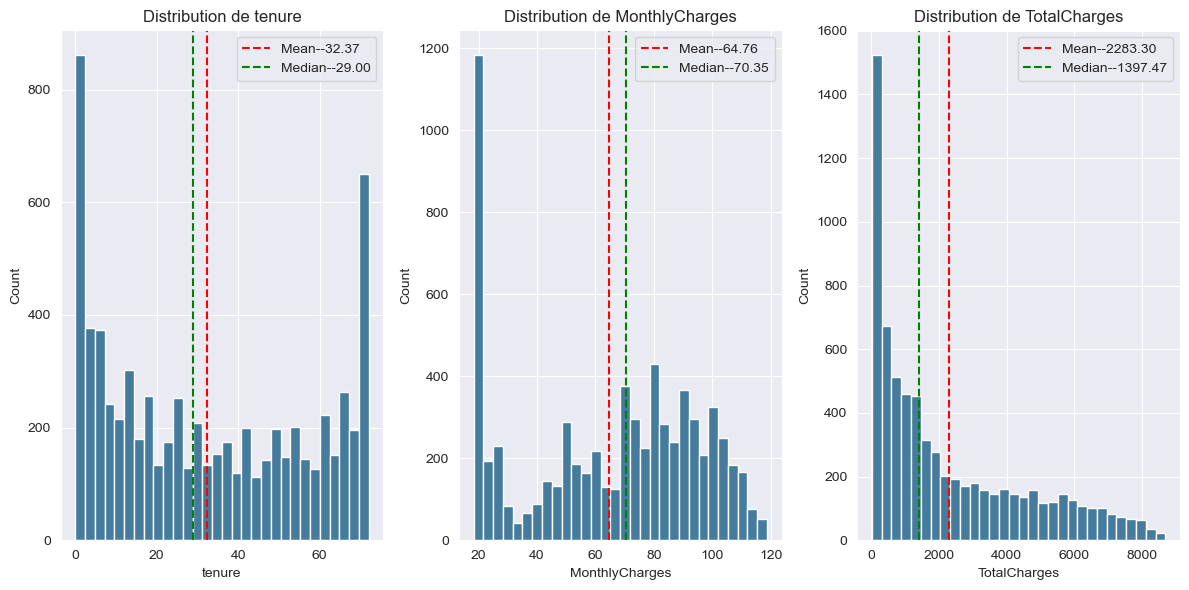

In [178]:
fig, ax = plt.subplots(1,3, figsize=(12,6))
ax = ax.flatten()

for i , val in enumerate(num_feature):
    ax[i].hist(data[val].dropna() , bins=30, color="#457B9D" , edgecolor="white")
    ax[i].axvline(data[val].mean(), linestyle="--" , color = "red", label = f"Mean--{data[val].mean():.2f}")
    ax[i].axvline(data[val].median(), linestyle="--", color="green", label= f"Median--{data[val].median():.2f}")
    ax[i].set_title(f"Distribution de {val}")
    ax[i].set_xlabel(f"{val}")
    ax[i].set_ylabel("Count")
    ax[i].legend()

fig.savefig("../data/hisplot_univariate")
plt.tight_layout()
plt.show()

## 📊 Interpretation: Univariate Distribution of Numerical Variables

* **tenure**: **bimodal** distribution — a large spike at 0–1 month (≈850 brand-new customers) and a second peak around 70–72 months (≈650 highly loyal customers). Mean (32.4) > median (29.0), slight right skew.

* **MonthlyCharges**: also bimodal — a strong spike around \$20 (customers with few add-ons) and a broader bump between \$70–100 (fiber + add-on customers). Mean (64.8) < median (70.4).

* **TotalCharges**: strongly right-skewed distribution (mean 2,283 well above median 1,397), a direct reflection of the tenure × MonthlyCharges product.

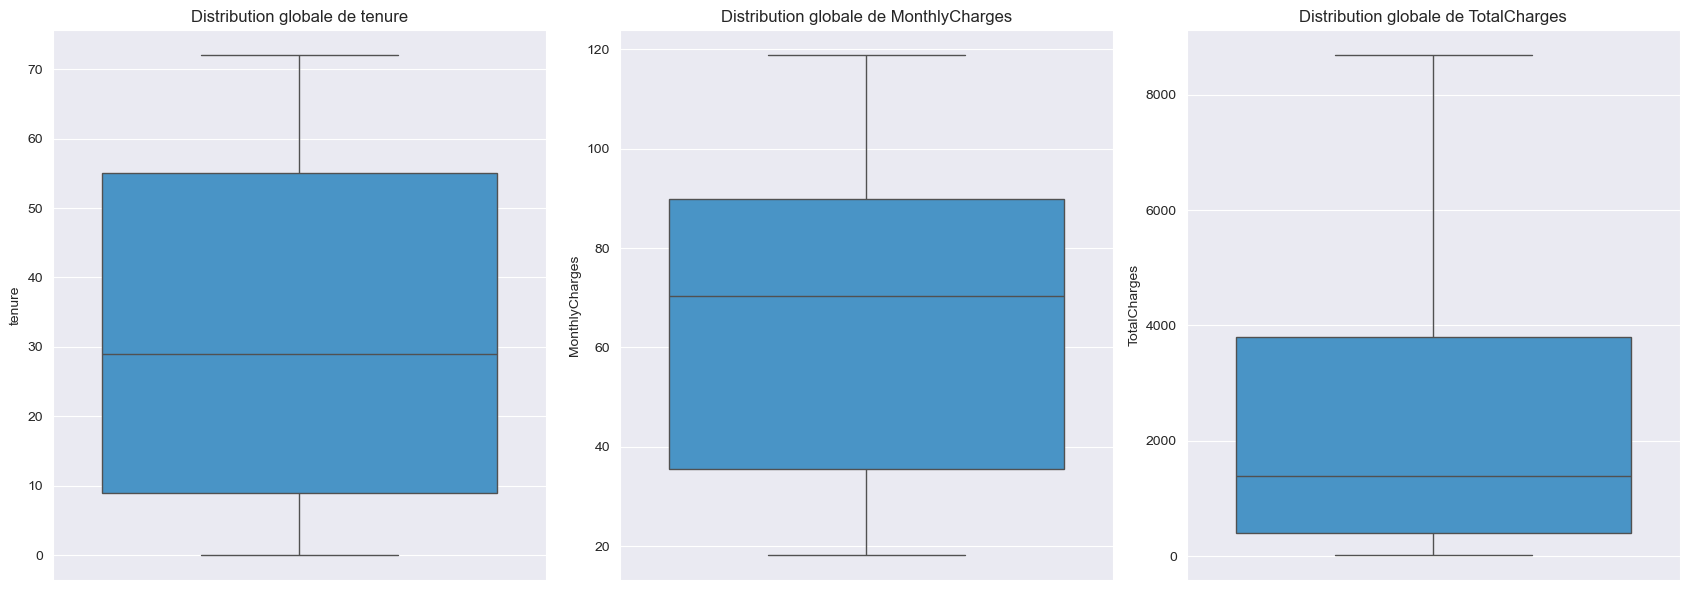

In [179]:
fig, ax = plt.subplots(1, 3, figsize=(17, 6))
ax = ax.flatten()


for i, col in enumerate(num_feature):
    # On supprime x="stroke" et hue="stroke" pour avoir la distribution globale
    sns.boxplot(
        data=data, 
        y=col, 
        ax=ax[i], 
        color="#3498db" # Une seule couleur pour l'ensemble du jeu de données
    )
    
    ax[i].set_title(f"Distribution globale de {col}")
    ax[i].set_ylabel(col)
fig.savefig("../data/boxplot_univariate")
plt.tight_layout()
plt.show()

## 📊 Interpretation: Boxplots of Numerical Variables

* **tenure**: median ≈ 29 months, IQR [9; 55]. Spread-out distribution with no detected outliers (natural bounds 0–72 months).

* **MonthlyCharges**: median ≈ \$70, IQR [35; 90]. No outliers, slight skew toward lower values.

* **TotalCharges**: median ≈ \$1,400, IQR [400; 3,800]. The upper whisker extends to about \$8,700, revealing a **strong right skew**, consistent with the fact that this variable is a cumulative amount tied to `tenure`.

* **Conclusion**: no numerical variable shows extreme outliers under the IQR method — no aggressive outlier treatment needed at this stage.

## ANALYSE BIVARIEE

In [140]:
## Feature Numeric & Target 

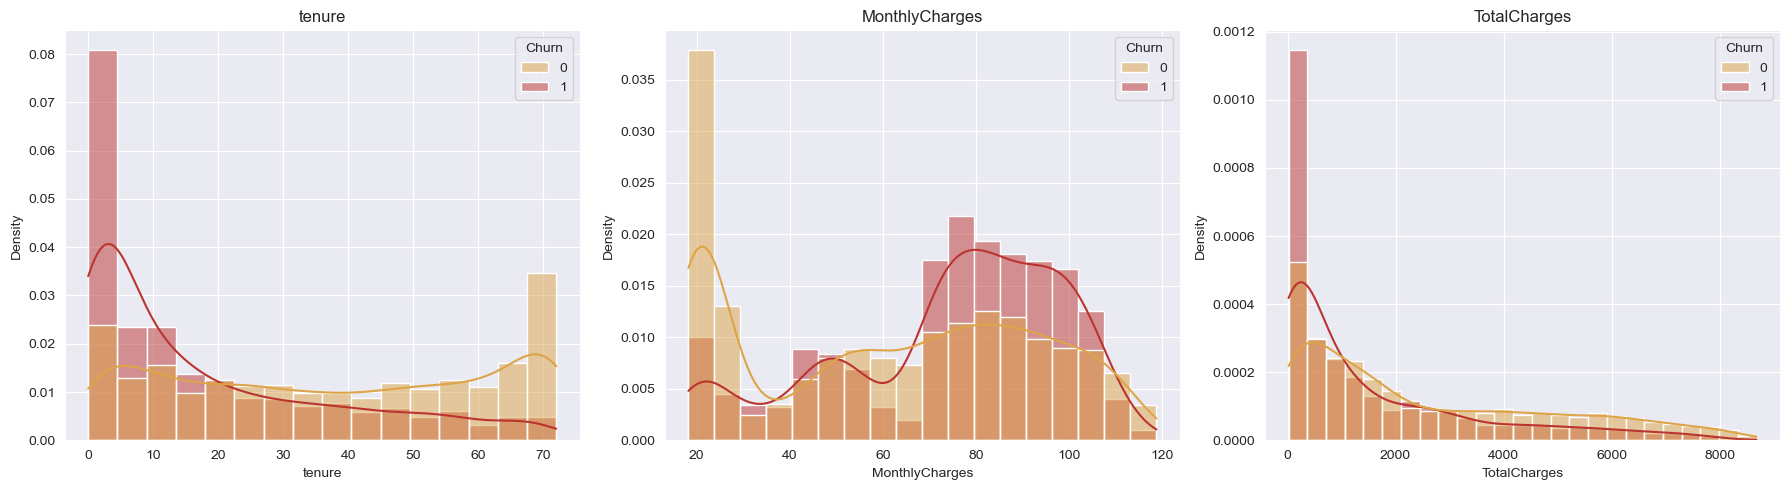

In [153]:

fig, ax = plt.subplots(1, len(num_feature), figsize=(18, 5))

for index, val in enumerate(num_feature):
    sns.histplot(
        data=data, 
        x=val, 
        hue="Churn",  
        kde=True,          
        stat="density",     
        common_norm=False,  
        palette=["#DDA448", "#BB342F"],
        alpha=0.5,          
        ax=ax[index]
    )
    
    ax[index].set_title(val)
fig.savefig("../data/hisplot_bivariate")
plt.tight_layout()
plt.show()

## 📊 Interpretation: Numerical Distributions Cross-Tabulated with Churn

* **tenure vs Churn**: the **most visually discriminative variable**. Churners are heavily concentrated in the first months of subscription (a sharp spike near 0), while non-churners are more evenly spread with a peak around 70 months.

* **MonthlyCharges vs Churn**: non-churners show a clear spike around \$20 (simple contracts), while churners are concentrated between \$70–100 — consistent with the hypothesis that fiber optic and high charges drive attrition.

* **TotalCharges vs Churn**: churners are concentrated at low values, but this effect is **mechanically tied to their low tenure** rather than an independent signal (cf. the 0.83 correlation with tenure) — should not be over-interpreted as a distinct causal factor.

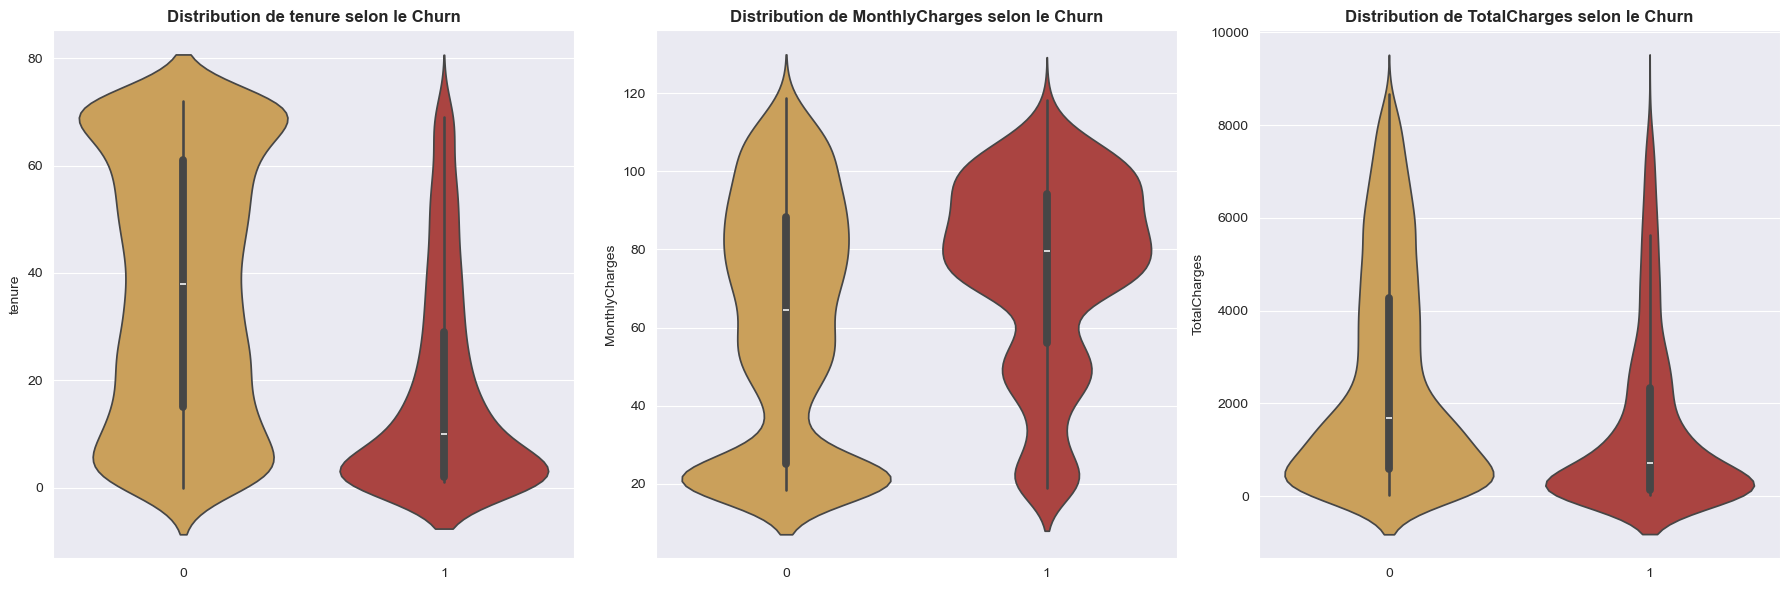

In [152]:


fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for index, val in enumerate(num_feature):
    
    sns.violinplot(
        data=data, 
        x="Churn", 
        y=val, 
        hue="Churn", 
        legend=False,
        palette=["#DDA448", "#BB342F"], 
        ax=ax[index]
    )
    
    ax[index].set_title(f"Distribution de {val} selon le Churn", fontsize=12, fontweight='bold')
    ax[index].set_xlabel("")
    ax[index].set_ylabel(val)
    
fig.savefig("../data/violin_bivariate")
plt.tight_layout()
plt.show()

## 📊 Interpretation: Violin Plots of Numerical Variables by Churn

* **tenure**: the churners' violin is narrow and concentrated at the bottom (median ~10 months), shaped like a tight teardrop, versus a wide, evenly-spread violin for non-churners — confirms that churn risk is concentrated among recent customers.
* **MonthlyCharges**: the churners' violin is shifted upward with a clear bulge between $70–100, versus a large bulge near $20 for non-churners.
* **TotalCharges**: same pattern as the histograms — the churners' violin is tightly compressed near 0, reflecting their low tenure more than an independent signal.

## Feature Categorielle & Target

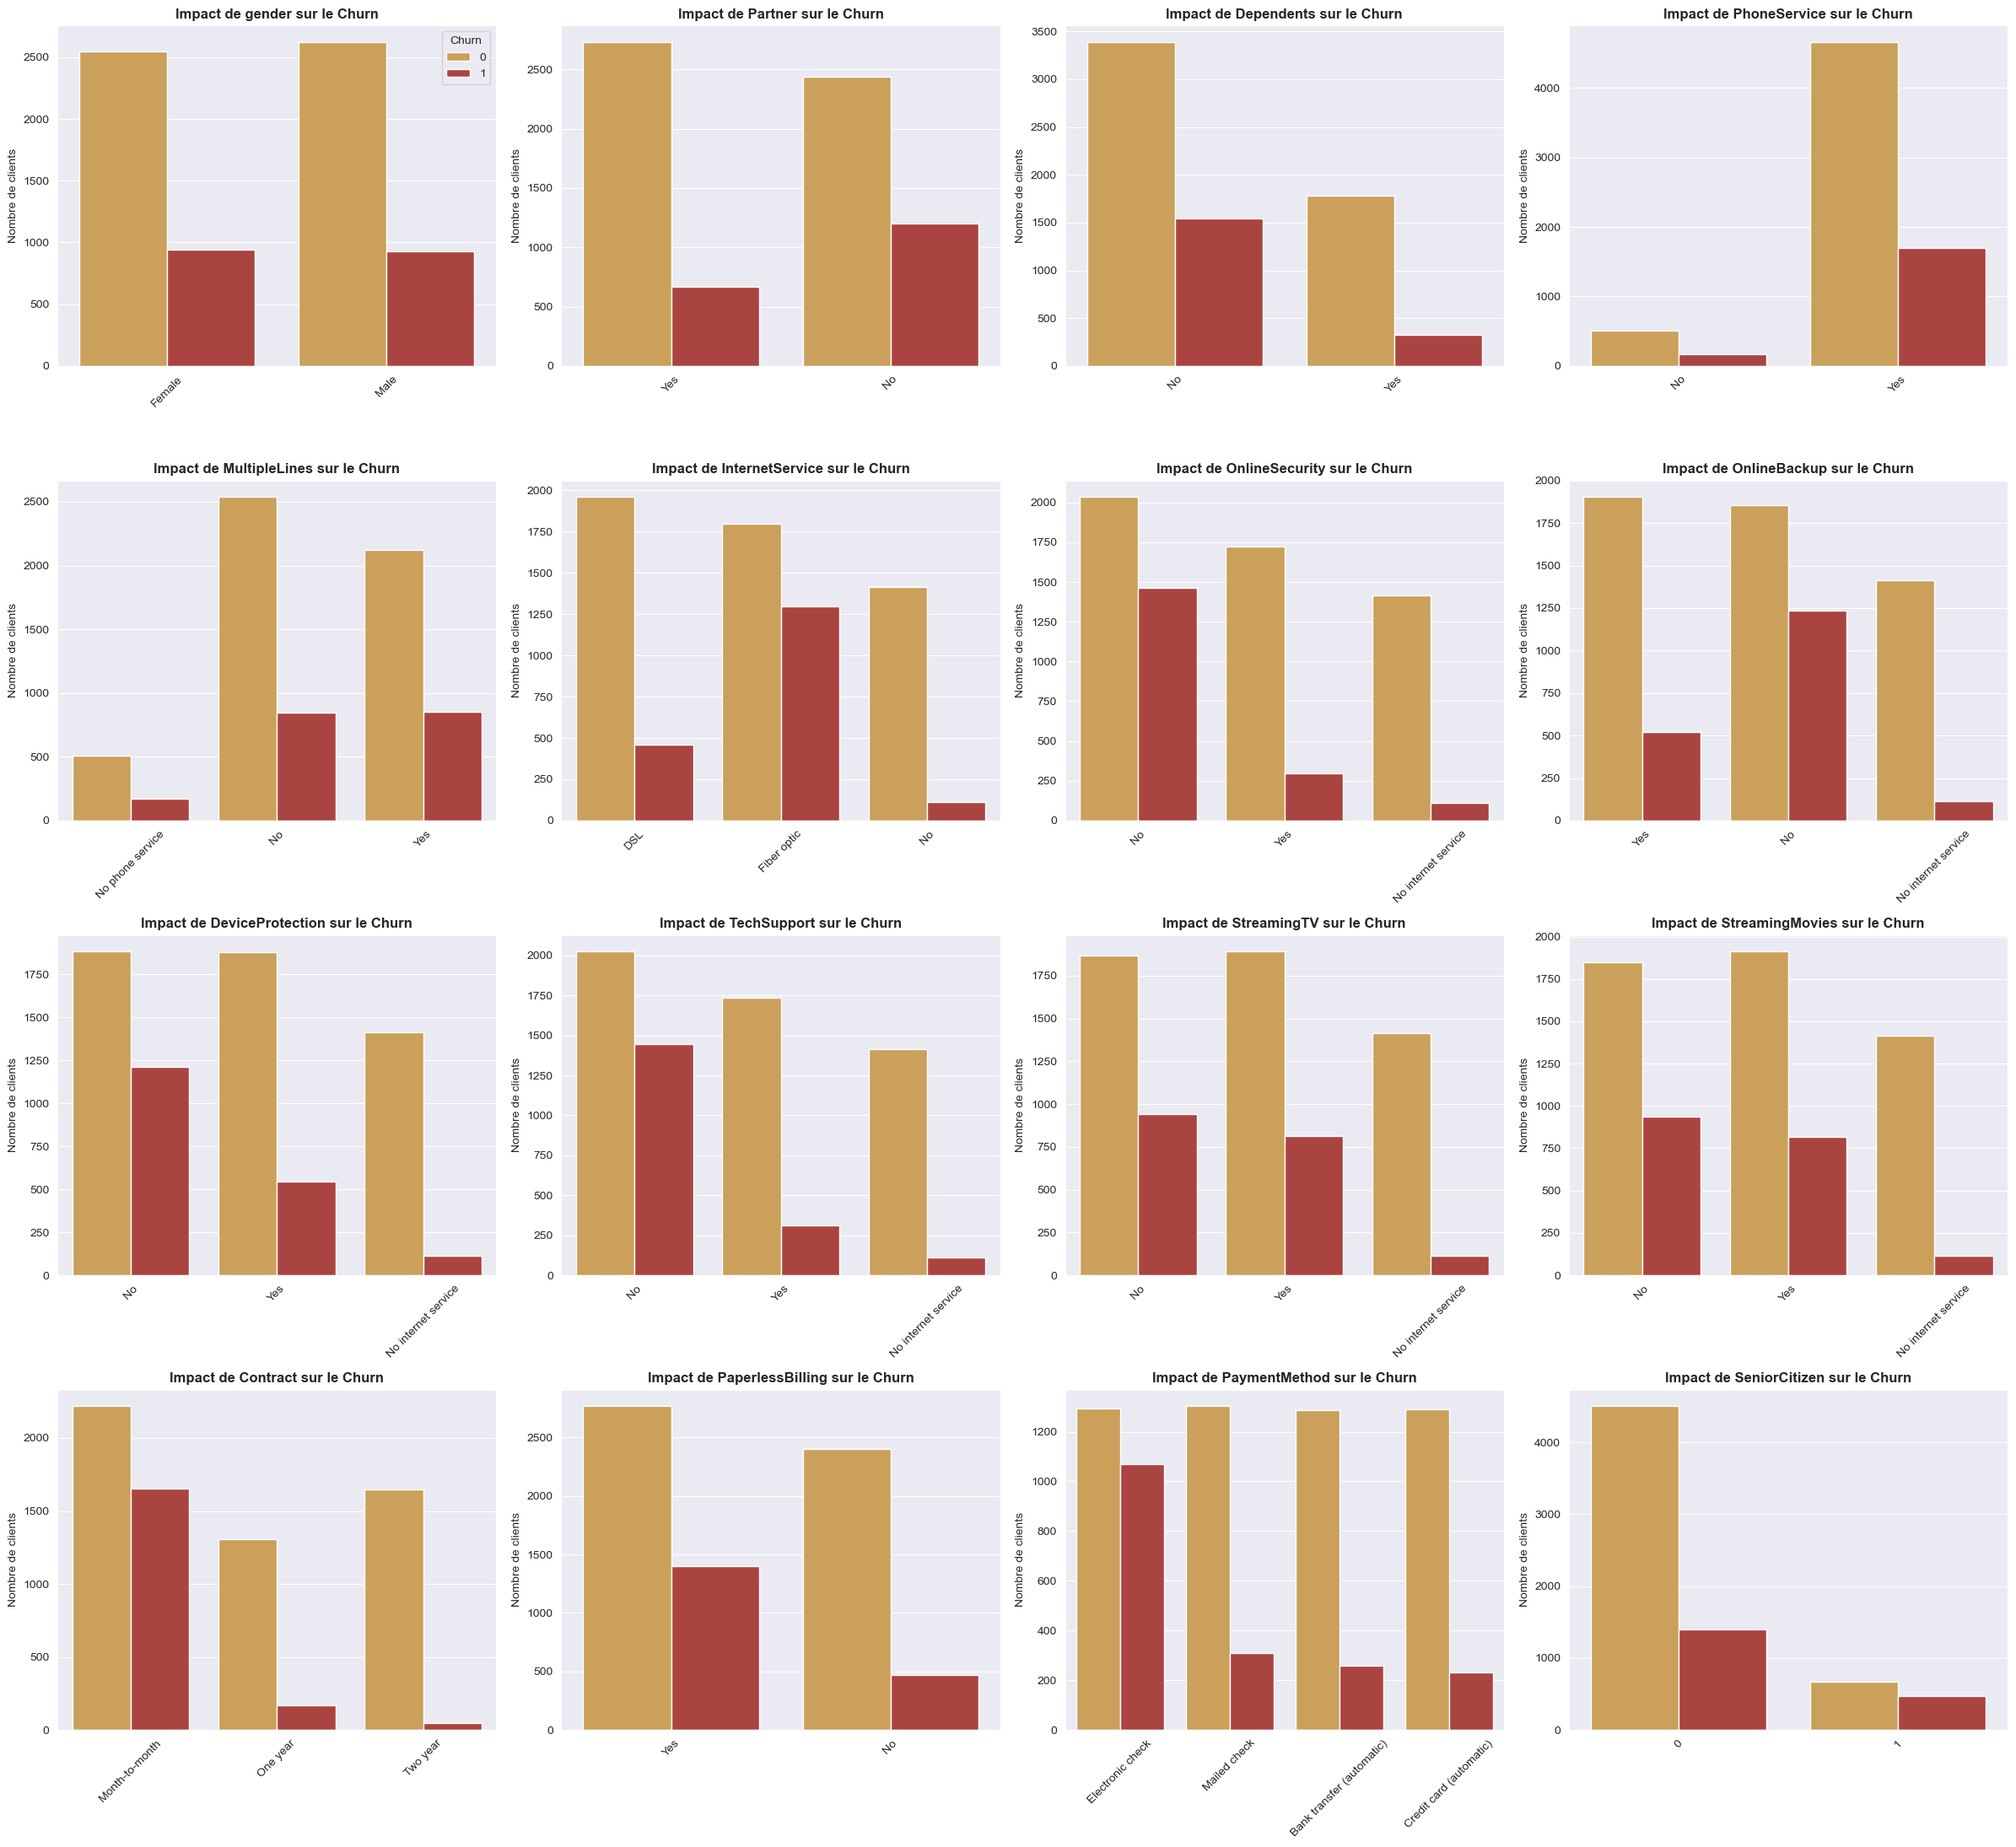

In [151]:


fig, ax = plt.subplots(4, 4, figsize=(24, 22))
ax = ax.flatten()

for index, val in enumerate(cat_feature):
    
    sns.countplot(
        data=data, 
        x=val, 
        hue="Churn", 
        palette=["#DDA448", "#BB342F"], # Or = No Churn, Rouge = Churn
        ax=ax[index]
    )
    
    
    ax[index].set_title(f"Impact de {val} sur le Churn", fontsize=12, fontweight='bold')
    ax[index].set_ylabel("Nombre de clients")
    ax[index].set_xlabel("")
    ax[index].tick_params(axis='x', rotation=45)
    
    
    if index != 0:
        ax[index].get_legend().remove()
fig.savefig("../data/bar_bivariate")
plt.tight_layout()
plt.show()

## 📊 Interpretation: Impact of Categorical Variables on Churn

* **Demographic profiles**: `gender` shows no visible impact. Customers without a `Partner` or without `Dependents` churn proportionally more. `SeniorCitizen` customers show a higher churn rate, despite a small senior sample size.
* **Internet services**: `InternetService` = "Fiber optic" shows a markedly higher churn rate than DSL or no internet — a major risk factor. The **absence** of `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, and `TechSupport` is consistently associated with much higher churn than their presence — `TechSupport = "No"` stands out particularly strongly.
* **StreamingTV / StreamingMovies**: more moderate effect compared to security/support add-ons.
* **Contract**: **the single most discriminative variable in the entire dataset**. "Month-to-month" accounts for the vast majority of churners, versus near-zero churn for "Two year" contracts.
* **PaperlessBilling**: customers with paperless billing churn more.
* **PaymentMethod**: "Electronic check" stands out as strongly associated with churn, unlike automatic payment methods (bank transfer, credit card), which are much more stable.
* **Conclusion**: the most predictive variables are `Contract`, `tenure`, `InternetService` (fiber), `TechSupport`, `OnlineSecurity`, `PaymentMethod` (electronic check), and `MonthlyCharges`. In contrast, `gender`, `PhoneService`, and `MultipleLines` carry little predictive value.

## HEATMAPS

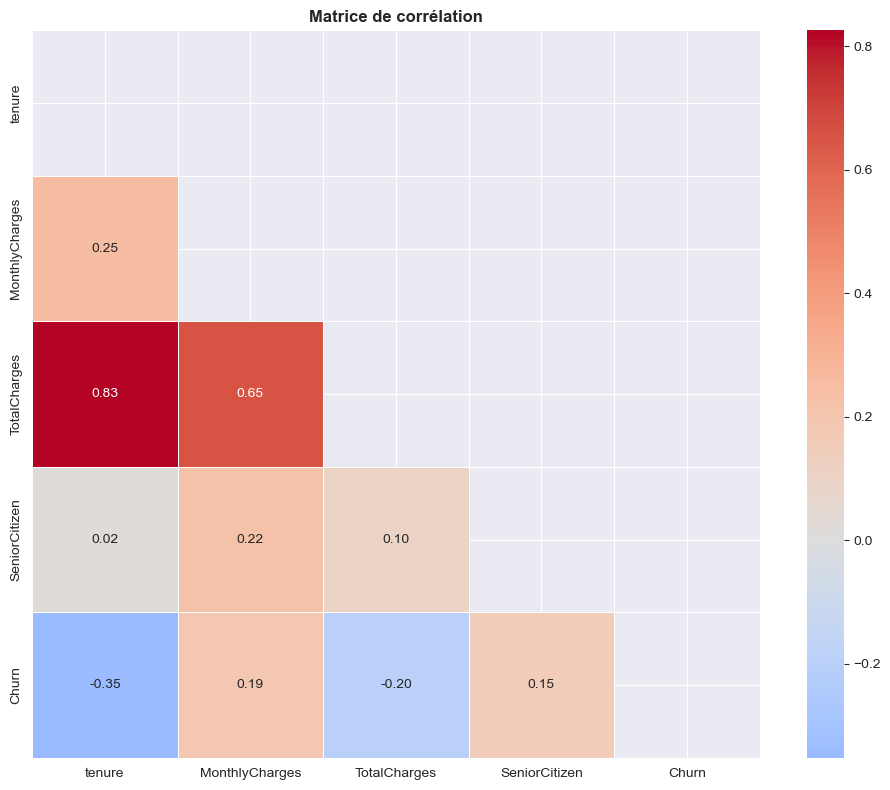

In [149]:
num_vars = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]

fig = plt.figure(figsize=(10, 8))  # on capture bien la figure ici
corr = data[num_vars].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0, 
    square=True, 
    linewidths=0.5
)

plt.title("Matrice de corrélation", fontweight='bold')
plt.tight_layout()

# Sauvegarde APRÈS titre + tight_layout, AVANT show
fig.savefig("../data/correlation.png", dpi=300, bbox_inches="tight")

plt.show()

## 📊 Interpretation: Correlation Matrix of Numerical Variables

* **tenure ↔ TotalCharges (r = 0.83)**: very strong, expected correlation — the longer a customer stays, the higher their cumulative billed amount. **Multicollinearity risk** to watch for linear models (logistic regression): consider dropping one of the two variables or using regularization (Ridge/Lasso).
* **MonthlyCharges ↔ TotalCharges (r = 0.65)**: strong correlation, also expected since TotalCharges is partly derived from the cumulative monthly amount.
* **tenure ↔ MonthlyCharges (r = 0.25)**: weak correlation — both variables carry largely independent information.
* **tenure ↔ Churn (r = -0.35)**: the **strongest correlation with the target** among numerical variables. Higher tenure is associated with lower churn — consistent with the bivariate histograms.
* **TotalCharges ↔ Churn (r = -0.20)**: moderate negative correlation, but likely **redundant with tenure** (indirect effect via the strong tenure/TotalCharges correlation) rather than an independent signal.
* **MonthlyCharges ↔ Churn (r = 0.19)**: moderate positive correlation — higher monthly charges are associated with slightly higher churn risk, consistent with the fiber-optic effect observed earlier.
* **SeniorCitizen ↔ Churn (r = 0.15)**: weak but positive correlation — being a senior citizen is a mild risk factor, consistent with the corresponding bar chart.
* **Conclusion for modeling**: `tenure` is the most predictive numerical variable for churn. `TotalCharges` adds little additional information once `tenure` is known — worth considering for removal or feature engineering (e.g., a TotalCharges/tenure ratio) to reduce collinearity.

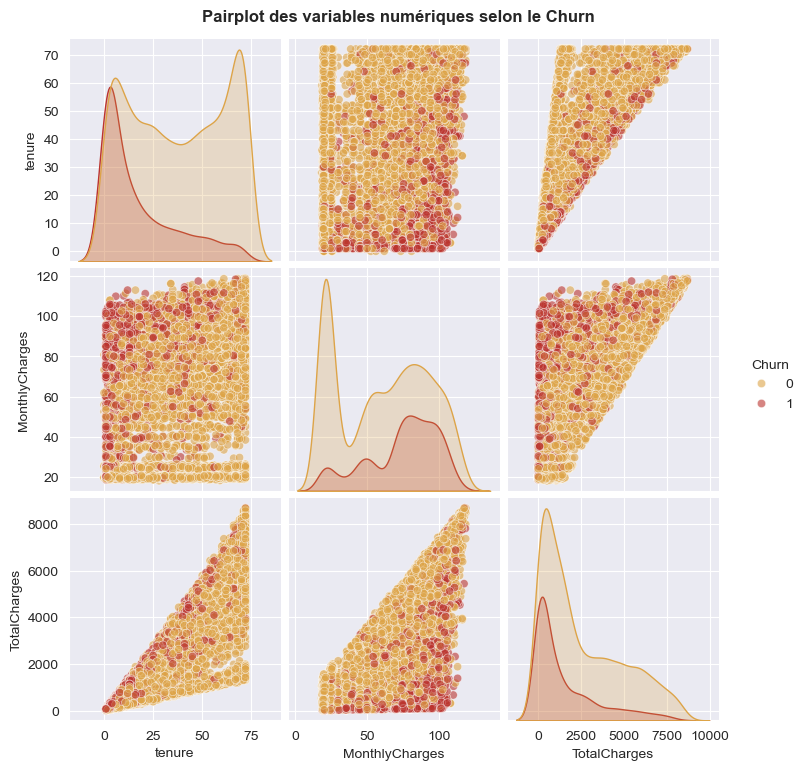

In [150]:
g = sns.pairplot(
    data[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], 
    hue="Churn", 
    palette=["#DDA448", "#BB342F"],
    plot_kws={'alpha': 0.6}
)

g.fig.suptitle("Pairplot des variables numériques selon le Churn", y=1.02, fontweight='bold')

g.savefig("../data/pairplot.png", dpi=300, bbox_inches="tight")

plt.show()

## 📊 Interpretation: Pairplot of Numerical Variables by Churn

* **Diagonal (KDE densities)**: confirms the univariate observations — `tenure` and `MonthlyCharges` are bimodal, `TotalCharges` is strongly right-skewed. For all three variables, the churner density (red) is **consistently concentrated at lower values**, while the non-churner density (orange) is more spread out.
* **tenure vs MonthlyCharges**: the scatter shows no clean separation between the two classes — red (churn) points are scattered across the full MonthlyCharges range but concentrated at low tenure values. This confirms that **tenure discriminates churn better than MonthlyCharges alone**.
* **tenure vs TotalCharges**: near-linear, triangular-shaped relationship (rising upper bound), visually illustrating the strong correlation (0.83) — TotalCharges cannot exceed tenure × max MonthlyCharges, producing this characteristic shape.
* **MonthlyCharges vs TotalCharges**: more scattered relationship, since it also depends on tenure.
* **Conclusion**: the pairplot visually confirms there is no perfect separation between churners and non-churners on any single pair of numerical variables — a model will need to combine multiple features (numerical + categorical) to discriminate effectively between the two classes.